### Leaf segmenter

In [35]:
from ultralytics import YOLO

import cv2, numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib import cm
%matplotlib inline  

import os, glob
import numpy as np
from PIL import Image

SEG_DIR = 'output_segmented'

w = 224
h = 224

In [ ]:
# The fine-tuned weights are committed at runs/segment/train/weights/best.pt --
# YOLO11n-seg, 100 epochs on the olive dataset, see runs/segment/train/args.yaml.
# The previous value, "yolo_segmenter_weights.pt", is not in the repository under
# that name, so this cell failed on a fresh clone.
CANDIDATES = ('runs/segment/train/weights/best.pt',
              '../runs/segment/train/weights/best.pt')
WEIGHTS = next((p for p in CANDIDATES if os.path.exists(p)), CANDIDATES[0])

leaf_segmenter_model = YOLO(WEIGHTS)
print("loaded YOLO:", leaf_segmenter_model.task, "| classes:", leaf_segmenter_model.names)

In [37]:
def segment_leaves(image, conf=0.25):
    """Full-size BGR images, one per leaf, background black. Largest leaf first."""
    res = leaf_segmenter_model.predict(image, conf=conf, retina_masks=True, verbose=False)[0]
    if res.masks is None:
        return []
    img = res.orig_img
    masks = res.masks.data.cpu().numpy().astype(np.uint8)
    masks = sorted(masks, key=lambda m: m.sum(), reverse=True)
    return [img * m[:, :, None] for m in masks]

In [38]:
IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'}

def list_images(folder):
    return sorted(os.path.join(folder, f) for f in os.listdir(folder)
                  if os.path.splitext(f)[1].lower() in IMG_EXTS)

FOLDERS = {'data/internet': 0, 
           'data/olive_leaves/train/Healthy': 0,
           'data/olive_leaves/train/aculus_olearius': 1,
           'data/olive_leaves/train/olive_peacock_spot': 2,
           'data/olive_leaves/testing/images/Healthy': 0,
           'data/olive_leaves/testing/images/aculus_olearius': 1,
           'data/olive_leaves/testing/images/olive_peacock_spot': 2
          }

seg_info_rows = []      # one row per source image
segment_rows = []       # one row per output segment
for folder, label in FOLDERS.items():
    for filename in list_images(folder):

        # Load and resize
        im = Image.open(filename).convert('RGB').resize((w, h), Image.LANCZOS)
        rgb_full = np.array(im)
        bgr = cv2.cvtColor(rgb_full, cv2.COLOR_RGB2BGR)
        
        # Leaf segmentation
        leaves = segment_leaves(bgr)
        stem = os.path.splitext(os.path.basename(filename))[0]
        
        seg_info_rows.append({'path': filename,'folder': folder,'label': label,'n_leaves': len(leaves)})
        
        if leaves:
            for i, leaf in enumerate(leaves):
                rgb = cv2.cvtColor(leaf, cv2.COLOR_BGR2RGB)
                out = os.path.join(SEG_DIR, folder, f'{stem}_leaf{i:02d}.png')
                os.makedirs(os.path.dirname(out), exist_ok=True)
                Image.fromarray(rgb).save(out)
                segment_rows.append({'src_path': filename, 'folder': folder, 'label': label,
                                     'stem': stem, 'leaf_idx': i, 'segmented': True,
                                     'seg_path': out, 'image': rgb})
        else:
            im = Image.open(filename).convert('RGB')
            out = os.path.join(SEG_DIR, folder, f'{stem}_full.png')
            os.makedirs(os.path.dirname(out), exist_ok=True)   # <- see note below
            im.save(out)
            segment_rows.append({'src_path': filename, 'folder': folder, 'label': label,
                                 'stem': stem, 'leaf_idx': -1, 'segmented': False,
                                 'seg_path': out, 'image': np.array(im)})

segments_df = pd.DataFrame(segment_rows)
print(len(segments_df), 'segments from', segments_df.src_path.nunique(), 'images')
segments_df.drop(columns='image').head()


3548 segments from 2756 images


,src_path,folder,label,stem,leaf_idx,segmented,seg_path
0,data/internet/bunch_olive_leaves_1.jpeg,data/internet,0,bunch_olive_leaves_1,0,True,output_segmented/data/internet/bunch_olive_lea...
1,data/internet/bunch_olive_leaves_1.jpeg,data/internet,0,bunch_olive_leaves_1,1,True,output_segmented/data/internet/bunch_olive_lea...
2,data/internet/bunch_olive_leaves_1.jpeg,data/internet,0,bunch_olive_leaves_1,2,True,output_segmented/data/internet/bunch_olive_lea...
3,data/internet/bunch_olive_leaves_1.jpeg,data/internet,0,bunch_olive_leaves_1,3,True,output_segmented/data/internet/bunch_olive_lea...
4,data/internet/bunch_olive_leaves_1.jpeg,data/internet,0,bunch_olive_leaves_1,4,True,output_segmented/data/internet/bunch_olive_lea...


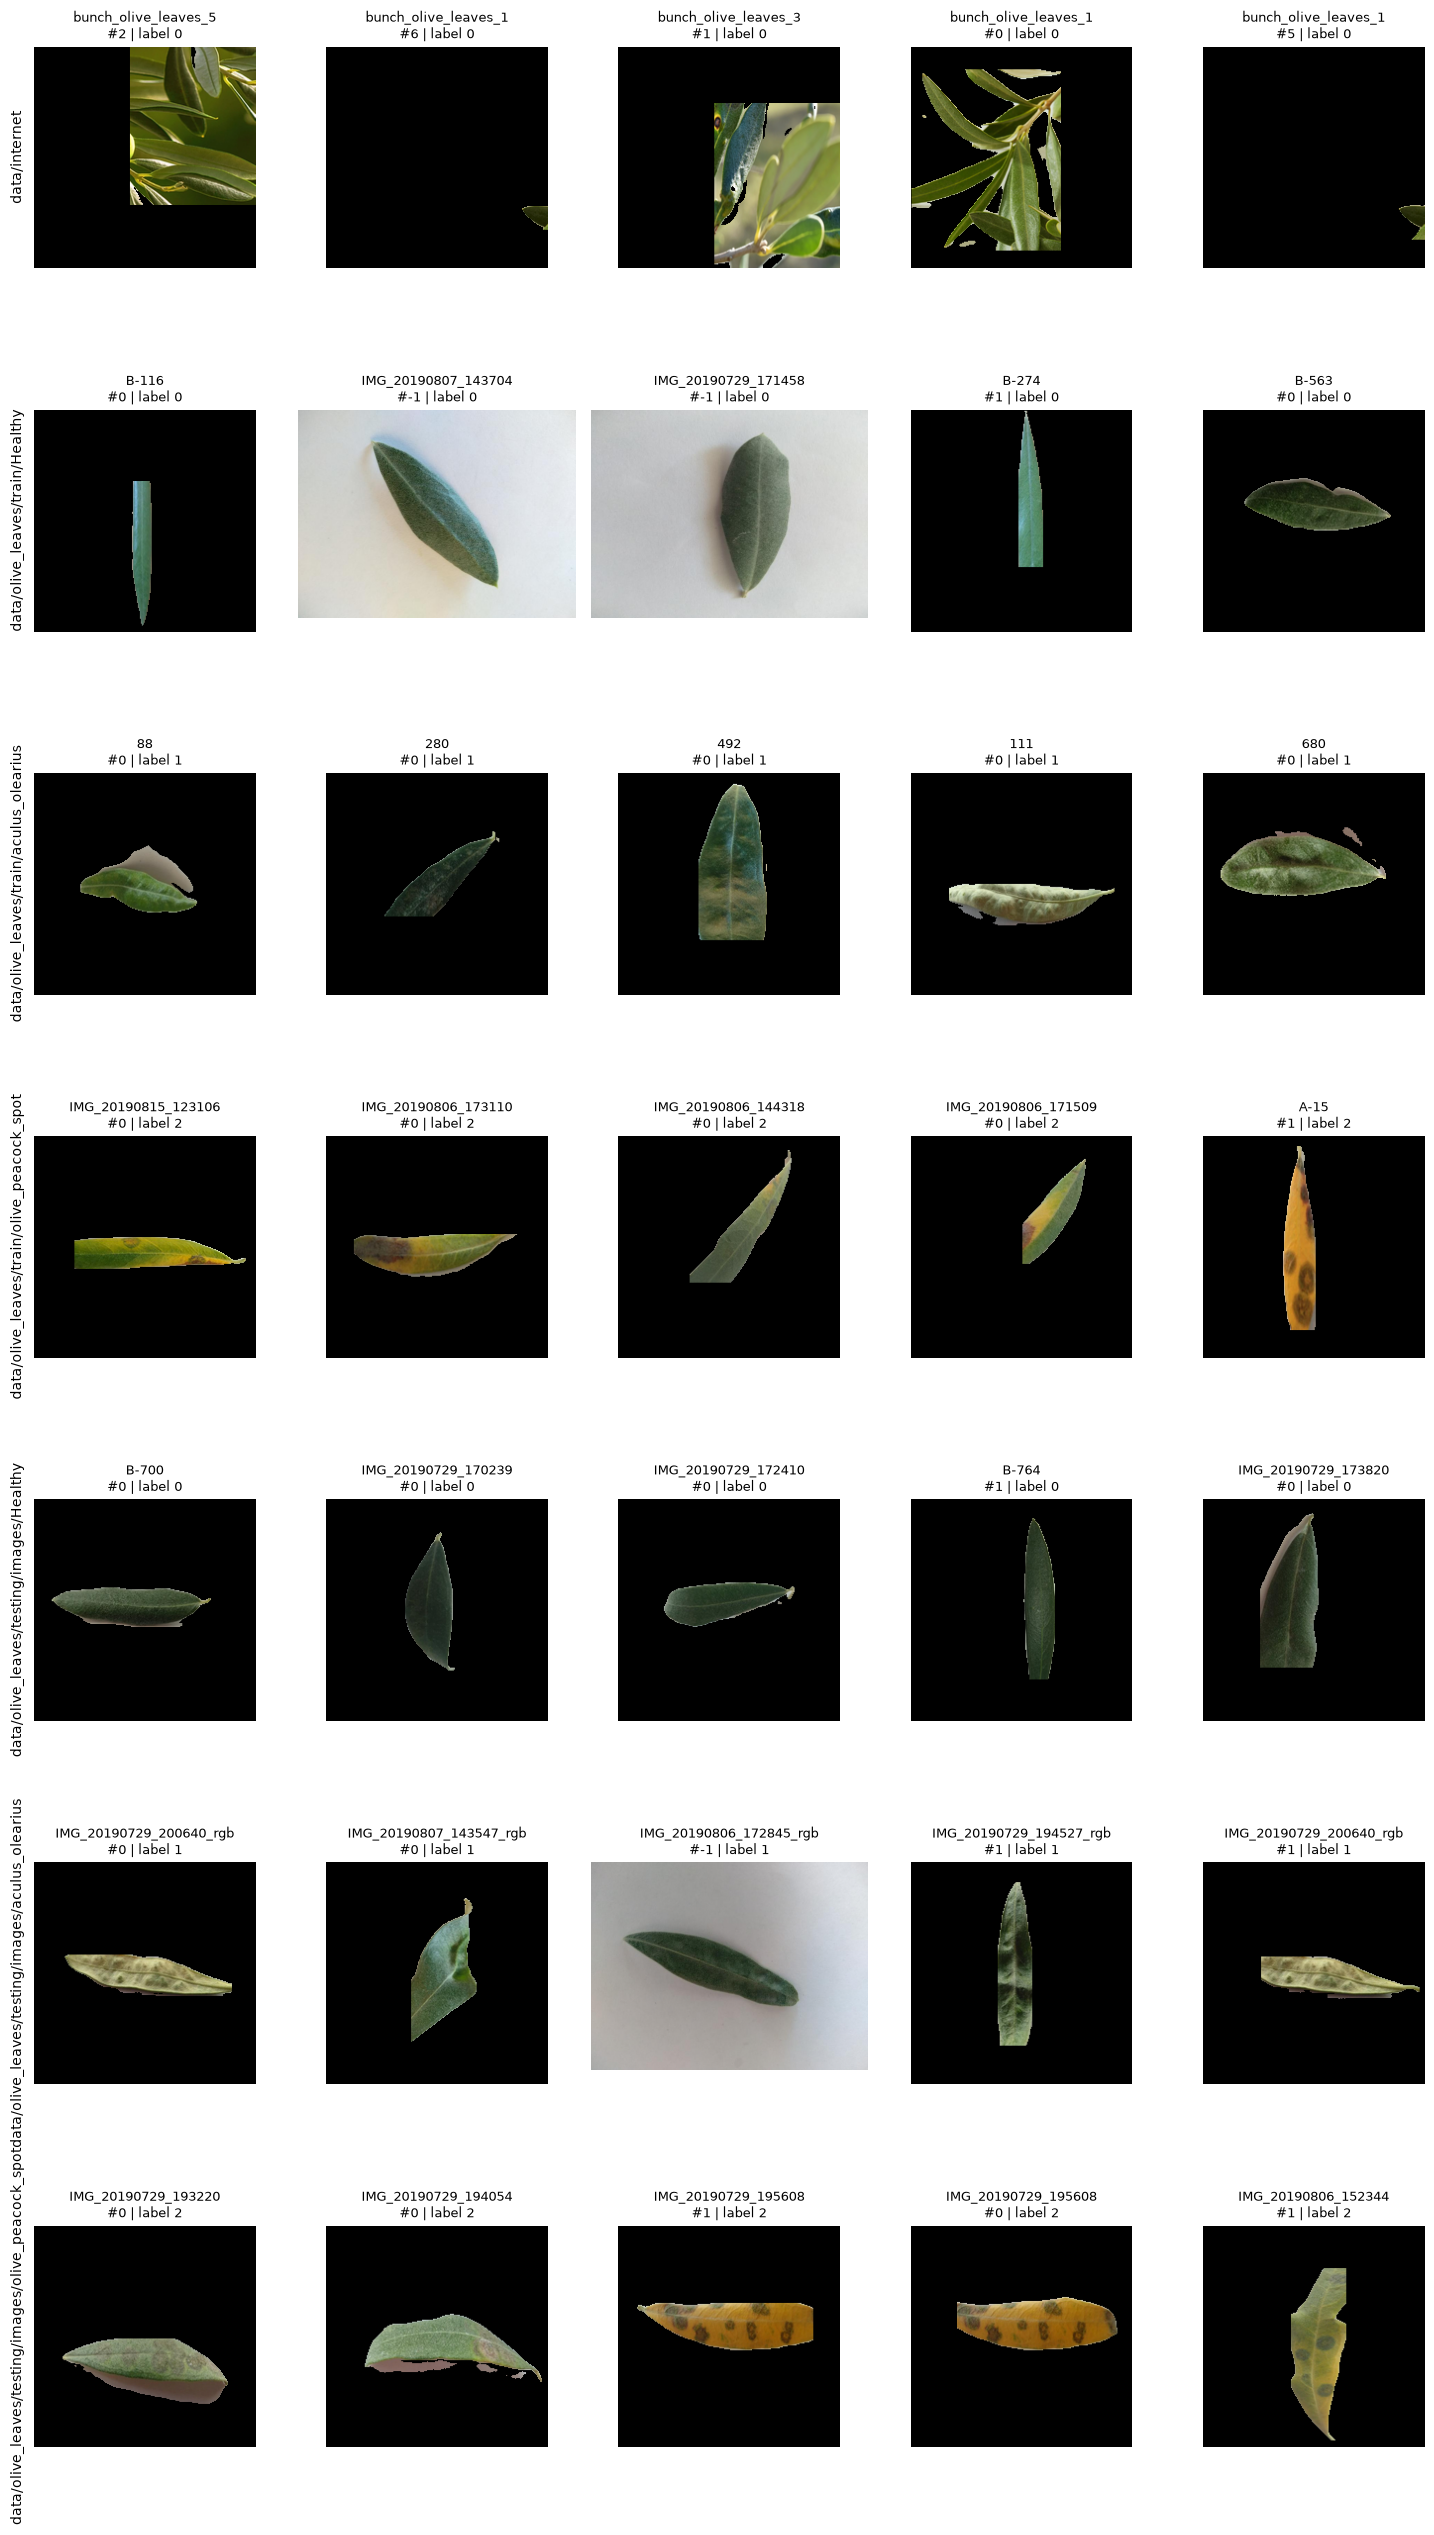

In [40]:
N_PER_FOLDER = 5

segs = segments_df                              # or: segments_df[segments_df.segmented]
folders = list(segs['folder'].unique())

fig, axes = plt.subplots(len(folders), N_PER_FOLDER,
                         figsize=(3 * N_PER_FOLDER, 3.6 * len(folders)),
                         squeeze=False)

for row_axes, folder in zip(axes, folders):
    group = segs[segs.folder == folder]
    sample = group.sample(min(N_PER_FOLDER, len(group)))

    for ax, (_, seg) in zip(row_axes, sample.iterrows()):
        ax.imshow(seg['image'])
        ax.set_title(f"{seg['stem']}\n#{seg['leaf_idx']} | label {seg['label']}", fontsize=9)
        ax.set_anchor('N')

    row_axes[0].annotate(folder, xy=(0, 0.5), xytext=(-12, 0),
                         xycoords='axes fraction', textcoords='offset points',
                         rotation=90, va='center', ha='center', fontsize=10)

    for ax in row_axes:                         # also blanks unused slots
        ax.axis('off')

plt.tight_layout()


In [31]:
# Save info of segmentation result
seg_result_df = pd.DataFrame(seg_info_rows)
seg_result_df.head()
seg_result_df[seg_result_df.n_leaves != 1]

,path,folder,label,n_leaves
0,data/internet/bunch_olive_leaves_1.jpeg,data/internet,0,6
1,data/internet/bunch_olive_leaves_2.jpeg,data/internet,0,4
2,data/internet/bunch_olive_leaves_3.jpeg,data/internet,0,2
4,data/internet/bunch_olive_leaves_5.jpeg,data/internet,0,2
5,data/internet/bunch_olive_leaves_6.jpeg,data/internet,0,0
...,...,...,...,...
2749,data/olive_leaves/testing/images/olive_peacock...,data/olive_leaves/testing/images/olive_peacock...,2,2
2750,data/olive_leaves/testing/images/olive_peacock...,data/olive_leaves/testing/images/olive_peacock...,2,2
2751,data/olive_leaves/testing/images/olive_peacock...,data/olive_leaves/testing/images/olive_peacock...,2,2
2754,data/olive_leaves/testing/images/olive_peacock...,data/olive_leaves/testing/images/olive_peacock...,2,2
